# Regrid population mask

Population data obtained and converted to lat/lon via: https://github.com/dougrichardson/demand_model/blob/main/04_population_masks.ipynb

In [1]:
import xarray as xr
import xesmf as xe

import matplotlib.pyplot as plt

#### Regrid to BARRA-C2 grid

In [2]:
# Open the new netcdf file
pop = xr.open_dataset("/g/data/w42/dr6273/work/data/ABS/ABS_population_density/apg22r_1_0_0.nc")

In [3]:
pop

<xarray.Dataset> Size: 312MB
Dimensions:             (y: 3800, x: 4100)
Coordinates:
  * y                   (y) float64 30kB -1.1e+06 -1.102e+06 ... -4.9e+06
  * x                   (x) float64 33kB -1.95e+06 -1.95e+06 ... 2.148e+06
    lat                 (y, x) float64 125MB ...
    lon                 (y, x) float64 125MB ...
Data variables:
    population_density  (y, x) float32 62MB ...

In [3]:
# Check population
pop.where(pop > 0)["population_density"].sum()

<xarray.DataArray 'population_density' ()> Size: 4B
array(25989126., dtype=float32)

Get ERA5 template and subset for Australia

In [8]:
template = xr.open_dataset(
    "/g/data/ob53/BARRA2/output/reanalysis/AUST-04/BOM/ERA5/historical/hres/BARRA-C2/v1/fx/sftlf/latest/sftlf_AUST-04_ERA5_historical_hres_BOM_BARRA-C2_v1.nc"
)

In [24]:
template

<xarray.DataArray 'sftlf' (lat: 850, lon: 1025)> Size: 3MB
[871250 values with dtype=float32]
Coordinates:
  * lat      (lat) float64 7kB -43.97 -43.93 -43.89 ... -10.09 -10.05 -10.01
  * lon      (lon) float64 8kB 113.0 113.1 113.1 113.1 ... 153.9 153.9 154.0
    crs      int32 4B ...
Attributes:
    long_name:      Percentage of the grid  cell occupied by land (including ...
    standard_name:  land_area_fraction
    units:          %
    frequency:      fx
    grid_mapping:   crs

In [14]:
template = template.sftlf.sel(lon=slice(113, 154), lat=slice(-44, -10))

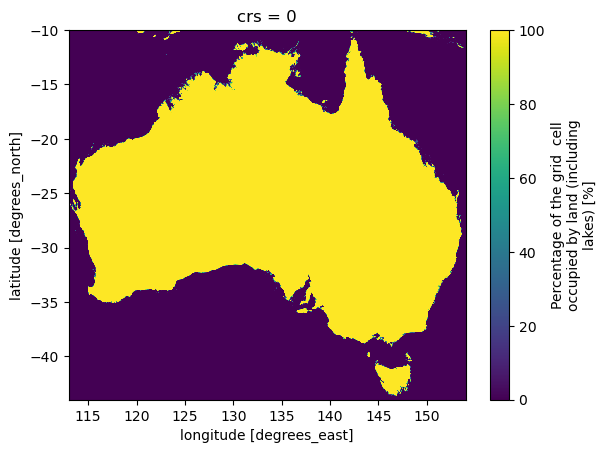

In [15]:
template.plot()

Use the coordinates to set up the desired output grid

In [16]:
ds_out = xr.Dataset({
    "lat": (["lat"], template["lat"].values, {"units": "degrees_north"}),
    "lon": (["lon"], template["lon"].values, {"units": "degrees_east"}),
})

#### Re-grid - needs a lot of compute.
I'm using the largest compute size on ARE (28 CPUs, 252G memory), but probably can go smaller.

In [17]:
%%time
regridder =  xe.Regridder(pop, ds_out, "nearest_d2s")

CPU times: user 1min 28s, sys: 3.92 s, total: 1min 32s
Wall time: 1min 32s


In [18]:
pop_barra = regridder(pop, keep_attrs=True)

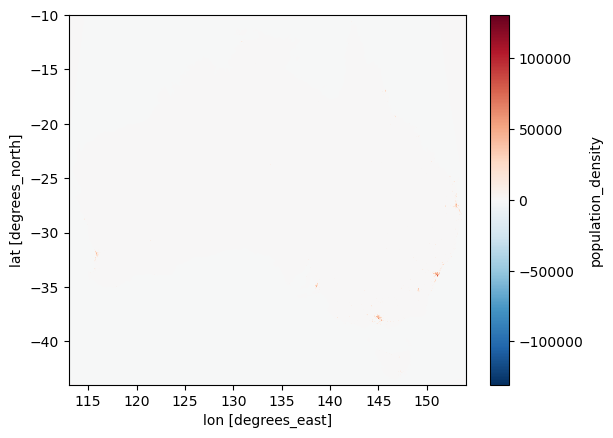

In [26]:
pop_barra.population_density.plot()

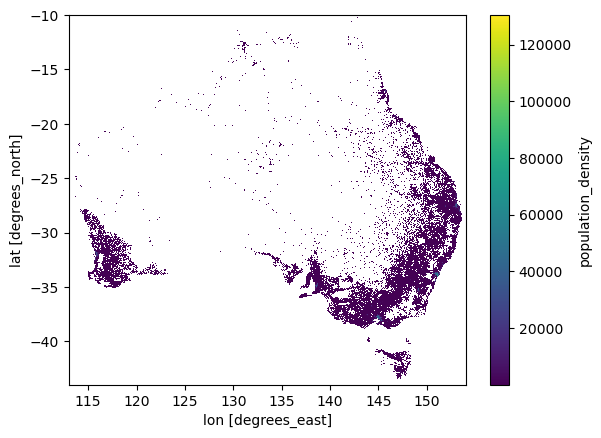

In [36]:
pop_barra.population_density.where(pop_barra.population_density > 0).plot()

In [20]:
pop_barra.where(pop_barra > 0)["population_density"].sum()

<xarray.DataArray 'population_density' ()> Size: 4B
array(25977364., dtype=float32)

Write to file

In [39]:
pop_barra.to_netcdf("/g/data/w42/dr6273/work/data/ABS/ABS_population_density/population_density_barra-c2_grid.nc")